# Health Projects — Supply Chain Impact Analysis  ·  Tiers 0–10

Multi-tier, multi-database supply-chain impact assessment for three health
infrastructure projects from the FAST-Infra labelling dataset spanning LATAM,
Africa, and Europe.  All four calibrated MRIO databases
(EXIOBASE 3.8, Eora26, WIOD 2016, OECD ICIO v2021) are run in parallel so
cross-database uncertainty can be read directly from the results.

**Supply-chain tier convention:**
> **Tier 0** — the project's own one-time transaction: investment paid directly to
> construction firms, medical-equipment manufacturers, energy suppliers, etc.
> (`SECTOR_ALLOC` vector).  One sector, one country per line item.  The impact
> indicators of this transaction are shown in Section 4.  No Leontief inversion.
>
> **Tier 1** — the Tier 0 spend aggregated into the upstream supply chain.  Each
> Tier 0 supplier now buys its own inputs from different sectors and countries.
> This is `y₁ = A · y₀` and includes a bilateral sourcing-country breakdown.
>
> **Tier n** — the n-th upstream round: `yₙ = Aⁿ · y₀`.

| Project ID | Region | Stage | Investment (USD) | IO sector model | Beneficiaries |
|---|---|---|---|---|---|
| **Proj_001** | LATAM | Development | $250,000,000 | `Health_Social` | 5,000,000 |
| **Proj_002** | Africa | Development | $25,000,000 | `Health_Specialized` | 3,000 |
| **Proj_003** | Europe | Operational | $75,000,000 | `Health_General` | 500,000 |

### Analysis layers
| Layer | What it captures |
|---|---|
| **Tier 0** | One-time transaction — investment distributed across direct supplying sectors; impact shown per sector (`y₀ = alloc × invest_M$`) |
| **Tier 1** | First upstream round — Tier 0 spend aggregated into the supply chain across sectors and countries (`y₁ = A · y₀`) + bilateral sourcing-country breakdown |
| **Tier 2** | Second upstream round — Tier 1 suppliers' own supply chain (`y₂ = A² · y₀`) |
| **Tiers 3–10** | Deep upstream rounds, per-tier and aggregated (`yₙ = Aⁿ · y₀`) |
| **Cumulative** | T0 + T1 + T2 + T3–10 stacked by tier group |


In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:,.3f}".format)
pd.set_option("display.max_columns", 20)

sys.path.insert(0, str(Path(".").resolve()))
from tvp_io_lib import tier0_impact, tier1_impact, tier_impact

IODB      = Path(".") / "input_iodb"
DATABASES = ["exiobase", "eora26", "wiod", "oecd"]
DB_LABEL  = {
    "exiobase": "EXIOBASE 3.8",
    "eora26":   "Eora26",
    "wiod":     "WIOD 2016",
    "oecd":     "OECD ICIO v2021",
}
INDICATORS = ["GHG_tCO2e", "Employment_FTE", "Water_1000m3", "ValueAdded_M$"]
DB_COLORS  = ["#2166ac", "#d73027", "#4dac26", "#f1a340"]

# Projects loaded directly from source data
# Investment already in USD (hospitals_finance_input.csv: Est_Investment_USD)
PROJECTS = [
    {"id": "Proj_001", "region": "LATAM",  "stage": "Development",
     "sector_code": "Health_Social",      "invest_usd": 250_000_000,
     "beneficiaries": 5_000_000, "care_type": "Primary / preventative care"},
    {"id": "Proj_002", "region": "Africa", "stage": "Development",
     "sector_code": "Health_Specialized", "invest_usd": 25_000_000,
     "beneficiaries": 3_000,     "care_type": "Tertiary / surgical care"},
    {"id": "Proj_003", "region": "Europe", "stage": "Operational",
     "sector_code": "Health_General",     "invest_usd": 75_000_000,
     "beneficiaries": 500_000,   "care_type": "General hospital services"},
]

print("Setup complete.")
print(f"  {'Project':<12} {'Region':<8} {'Stage':<14} {'Invest_MUSD':>12} {'Sector code'}")
for p in PROJECTS:
    print(f"  {p['id']:<12} {p['region']:<8} {p['stage']:<14} "
          f"  ${p['invest_usd']/1e6:>8.1f}M   {p['sector_code']}")


Setup complete.
  Project      Region   Stage           Invest_MUSD Sector code
  Proj_001     LATAM    Development      $   250.0M   Health_Social
  Proj_002     Africa   Development      $    25.0M   Health_Specialized
  Proj_003     Europe   Operational      $    75.0M   Health_General


---
## 1 · Source Data

### Financial Model Inputs (`modeled_input_data/`)

| Field | Type | Description |
|---|---|---|
| `Beneficiaries_H&S` | integer | Total direct beneficiaries — people with improved health outcomes; headline social-reach KPI |
| `Est_Investment_USD` | float | Estimated total investment in USD.  Already in USD — no currency conversion required |
| `Sector_Code` | string | IO sector archetype assigned based on care type and stage: `Health_Social` (large primary-care systems), `Health_Specialized` (surgical / tertiary), `Health_General` (district / rural hospitals) |
| `Multiplier_Benchmark` | float | Regional economic multiplier benchmark used for internal validation: ratio of total economic impact to direct investment.  LATAM = 2.1, Africa = 1.8, Europe = 2.0 |

> **Scale note:** The three projects span three orders of magnitude — $250M (Proj_001), $25M (Proj_002), $75M (Proj_003).
> Proj_001 is a systemic primary-care network (cost ~$50/person); Proj_002 is high-intensity specialised surgical
> care (~$8,000/person); Proj_003 is a large general hospital in operational phase.
> These very different cost-per-beneficiary profiles reflect the care-type assumption documented in
> `modeled_input_data/assumptions.txt` (Section 1: "The Capacity-to-Cost Link").


In [2]:
finance_df = pd.read_csv("modeled_input_data/hospitals_finance_input.csv")
display(finance_df)

,Project_ID,Region,Stage,Beneficiaries_H&S,Est_Investment_USD,Sector_Code,Multiplier_Benchmark
0,Proj_001,LATAM,Development,5000000,250000000,Health_Social,2.100
1,Proj_002,Africa,Development,3000,25000000,Health_Specialized,1.800
2,Proj_003,Europe,Operational,500000,75000000,Health_General,2.000


---
## 2 · MRIO Databases

All four calibrated databases are run in parallel.  When local files exist under
`input_iodb/` the pymrio backend is activated and bilateral trade shares are
extracted directly from the Z matrix; otherwise the calibrated parameter set
(derived from EXIOBASE 3.8 aggregates) is applied.

For health projects the choice of database is especially significant:
- **Eora26** is the preferred database for Proj_002 (Africa) — it resolves 190
  individual country tables rather than pooling sub-Saharan Africa into a
  Rest-of-World aggregate.
- **EXIOBASE 3.8** provides the most granular environmental satellite, capturing
  the high embodied carbon in medical equipment (Manufacturing sector).
- **WIOD 2016** gives the most reliable employment figures for Europe (Proj_003).
- **OECD ICIO v2021** is best for value-added decomposition, relevant for
  assessing the local economic multiplier of health investment.

| Database | Coverage | Data year | Key strength | Key limitation | Citation |
|---|---|---|---|---|---|
| **EXIOBASE 3.8** | 44 countries + 5 RoW · 163 sectors | 2018 | Widest environmental satellite (GHG species, water, land, materials, air pollutants) | Employment less detailed for services | Stadler et al. (2018), *J. Industrial Ecology* 22(3), doi:10.1111/jiec.12715 |
| **Eora26** | 190 countries · 26 sectors | 2015 | Highest country resolution — essential for Africa | 26 sectors; upward employment bias in developing countries | Lenzen et al. (2013), *Economic Systems Research* 25(1), doi:10.1080/09535314.2012.761953 |
| **WIOD 2016** | 43 countries + RoW · 56 sectors | 2014 | Best employment accounts (SEA: hours, compensation, skill levels) | No water satellite account | Timmer et al. (2015), *Review of International Economics* 23(3), doi:10.1111/roie.12178 |
| **OECD ICIO v2021** | 66 countries · 45 sectors | 2018 | Most policy-relevant; fully aligned with OECD TiVA; best for value-added decomposition | Fewer sectors; limited environmental satellite | OECD (2021), doi:10.1787/a8c8b9f0-en |


In [3]:
db_meta = pd.DataFrame([
    {"Database": "EXIOBASE 3.8",    "Countries": "44+5RoW", "Sectors": 163,
     "Data year": 2018, "Water satellite": "Yes",  "Employment satellite": "Basic"},
    {"Database": "Eora26",          "Countries": "190",     "Sectors": 26,
     "Data year": 2015, "Water satellite": "No",   "Employment satellite": "Yes (bias in dev. countries)"},
    {"Database": "WIOD 2016",       "Countries": "43+RoW",  "Sectors": 56,
     "Data year": 2014, "Water satellite": "No",   "Employment satellite": "Detailed (SEA)"},
    {"Database": "OECD ICIO v2021", "Countries": "66",      "Sectors": 45,
     "Data year": 2018, "Water satellite": "No",   "Employment satellite": "Standard"},
]).set_index("Database")
display(db_meta)


,Countries,Sectors,Data year,Water satellite,Employment satellite
Database,,,,,
EXIOBASE 3.8,44+5RoW,163,2018,Yes,Basic
Eora26,190,26,2015,No,Yes (bias in dev. countries)
WIOD 2016,43+RoW,56,2014,No,Detailed (SEA)
OECD ICIO v2021,66,45,2018,No,Standard


---
## 3 · Indicators & Tier Definitions

### Impact indicators

| Indicator | Unit | Scope | Source |
|---|---|---|---|
| `GHG_tCO2e` | tonnes CO₂-equivalent | Scope 3 upstream supply-chain GHG (CO₂, CH₄, N₂O, F-gases; IPCC AR6 GWP100 basis) | EXIOBASE 3.8 satellite; IEA *CO₂ Emissions from Fuel Combustion* 2022; IPCC AR6 WG3 Annex II |
| `Employment_FTE` | Full-Time Equivalent jobs | Supply-chain jobs supported — direct procurement + all upstream rounds | EXIOBASE 3.8 employment satellite; ILO *WESO* 2022; OECD STAN |
| `Water_1000m3` | 1,000 m³ (blue water withdrawal) | Freshwater withdrawn by the supply chain to produce purchased goods and services (withdrawal basis, not consumption) | Mekonnen & Hoekstra (2011) *HESS*; FAO AQUASTAT 2021; WRI Aqueduct 2019 |
| `ValueAdded_M$` | M USD | GDP contribution generated by the supply chain (gross output minus intermediate inputs) | OECD STAN 2022; World Bank WDI 2022 |

### Tier definitions

| Tier | Formula | Description |
|---|---|---|
| **Tier 0** | `S · diag(y₀)` where `y₀ = alloc × invest_M$` | Asset owner's one-time CAPEX transaction — investment distributed across direct procurement categories (contractors, equipment manufacturers, utilities directly contracted by the investor); no Leontief inversion |
| **Tier 1** | `S(src) · diag(trade_share[src] × A·y₀)` | Supply chain triggered by the Tier 0 payment — what Tier 0 contractors buy from their upstream suppliers (steel mills, cement plants, raw materials); intensity applied at the **sourcing country** |
| **Tier 2** | `S · diag(A²·y₀)` | Second upstream round — Tier 1 suppliers' own supply chain |
| **Tiers 3–10** | `S · diag(Aⁿ·y₀), n∈{3,…,10}` | Deep upstream rounds; each tier decays at ≈ spectral radius of A (≈ 0.52 for global EXIOBASE average) |

### Sector-allocation vectors used (share of investment to each supplying sector)

| Sector | Health_Social (large primary-care) | Health_Specialized (surgical/tertiary) | Health_General (district hospital) | Sources |
|---|---|---|---|---|
| Construction | 28 % | 22 % | 30 % | WHO (2020) Health Facility Construction Guidelines; World Bank HNP Notes |
| Energy / Utilities | 8 % | 7 % | 10 % | IEA (2022) Energy for Health — hospital energy benchmarks |
| Manufacturing | 25 % | 35 % | 22 % | Medical equipment, beds, surgical instruments — higher share for specialised |
| Transport / Logistics | 7 % | 6 % | 8 % | Supply chain logistics, ambulance fleet |
| Mining / Extraction | 18 % | 18 % | 15 % | Construction materials (cement, steel, glass) |
| Health / Social | 2 % | 1 % | 2 % | Administrative and social services |
| Water / Waste | 5 % | 6 % | 5 % | Medical waste treatment, water supply, sterilisation |
| Agriculture | 7 % | 5 % | 8 % | Catering, nutrition services, pharmaceuticals (plant-derived) |

> **Regional import leakage (LATAM/Africa):** Medical equipment (Manufacturing) has a high import
> content in LATAM and Africa — most diagnostic and surgical equipment is manufactured in
> Europe, the US, and Japan.  This "import leakage" is captured at Tier 1 through the bilateral
> trade shares derived from the OECD TiVA database: a higher foreign share is applied to the
> Manufacturing column of the A matrix for these regions.


In [4]:
ind_meta = pd.DataFrame([
    {"Indicator": "GHG_tCO2e",      "Unit": "tCO2e / M$", "Construction": 220.0, "Manufacturing": 380.0,
     "Health_Social": 140.0, "Agriculture": 150.0, "Mining": 320.0},
    {"Indicator": "Employment_FTE", "Unit": "FTE / M$",   "Construction": 14.0,  "Manufacturing": 8.0,
     "Health_Social": 18.0,  "Agriculture": 25.0,  "Mining": 7.0},
    {"Indicator": "Water_1000m3",   "Unit": "1000 m³ / M$","Construction": 0.80, "Manufacturing": 1.50,
     "Health_Social": 0.90,  "Agriculture": 5.00,  "Mining": 1.80},
    {"Indicator": "ValueAdded_M$",  "Unit": "M$ / M$",    "Construction": 0.48,  "Manufacturing": 0.42,
     "Health_Social": 0.70,  "Agriculture": 0.76,  "Mining": 0.56},
]).set_index("Indicator")
display(Markdown("**Global average stressor intensities (S_BASE) — sectors relevant to health projects**"))
display(ind_meta)
display(Markdown(
    "> Note: Health/Social carries the highest Employment intensity (18 FTE/M$) and "
    "a moderate GHG intensity (140 tCO2e/M$), reflecting labour-intensive care delivery "
    "with relatively low direct energy consumption.  Manufacturing is the dominant GHG "
    "driver due to the carbon-intensive production of medical equipment and building materials."
))


**Global average stressor intensities (S_BASE) — sectors relevant to health projects**

,Unit,Construction,Manufacturing,Health_Social,Agriculture,Mining
Indicator,,,,,,
GHG_tCO2e,tCO2e / M$,220.000,380.000,140.000,150.000,320.000
Employment_FTE,FTE / M$,14.000,8.000,18.000,25.000,7.000
Water_1000m3,1000 m³ / M$,0.800,1.500,0.900,5.000,1.800
ValueAdded_M$,M$ / M$,0.480,0.420,0.700,0.760,0.560


> Note: Health/Social carries the highest Employment intensity (18 FTE/M$) and a moderate GHG intensity (140 tCO2e/M$), reflecting labour-intensive care delivery with relatively low direct energy consumption.  Manufacturing is the dominant GHG driver due to the carbon-intensive production of medical equipment and building materials.

---
## 4 · Tier 0 — Direct Spend (the one-time transaction)

**Formula:** `impact₀ = S · diag(y₀)` where `y₀ = alloc × invest_M$`

Tier 0 is the **asset owner's one-time CAPEX transaction** to acquire or
commission the health asset.  The investment flows to the investor's **direct
procurement categories** — construction contractors, medical-equipment
manufacturers (imaging, diagnostics, surgical devices) that are directly
contracted, energy utilities, and logistics providers — as defined by the
project's `SECTOR_ALLOC` vector.  Steel mills, plastic resin producers, and
raw-material extractors are **not** Tier 0: they supply the Tier 0
contractors and appear at Tier 1.  **No Leontief inversion is applied.**

**Key regional GHG multipliers relative to global S_BASE baseline:**

| Region | Construction | Manufacturing | Health/Social | Energy/Utilities |
|---|---|---|---|---|
| Europe | 0.78 | 0.80 | 0.76 | 0.52 |
| LATAM | 0.95 | 1.10 | 1.05 | 1.25 |
| Africa | 1.10 | 1.20 | 1.15 | 1.90 |

Africa's high Energy/Utilities multiplier (1.90) reflects the dominance of diesel
and coal generation across sub-Saharan Africa (IEA, 2022).  LATAM Manufacturing
(1.10) reflects higher carbon intensity of industrial production relative to the
global average (EXIOBASE 3.8 regional decomposition).

**Employment note:** Africa and LATAM also carry **higher employment multipliers**
(Africa ≈ 1.58 ×, LATAM ≈ 1.22 × global average), meaning the same investment
generates proportionally more jobs in these regions — reflecting lower labour
productivity and higher labour intensity of construction (World Bank WDI, 2022).

**Source:** EXIOBASE 3.8 satellite accounts (Stadler et al. 2018);
IEA *World Energy Outlook 2022* Annex A; IPCC AR6 WG3 Table II.2;
World Bank WDI (2022) labour productivity by sector.


In [5]:
t0_rows = []
for p in PROJECTS:
    for db in DATABASES:
        r = tier0_impact(p["invest_usd"], p["sector_code"], p["region"],
                         database=db, iodb_path=IODB)
        t0_rows.append({
            "Project": p["id"], "Region": p["region"], "Stage": p["stage"],
            "Care_Type": p["care_type"],
            "Invest_MUSD": round(p["invest_usd"] / 1e6, 2),
            "Beneficiaries": p["beneficiaries"],
            "Database": DB_LABEL[db],
            "GHG_tCO2e":      r["GHG_tCO2e"],
            "Employment_FTE": r["Employment_FTE"],
            "Water_1000m3":   r["Water_1000m3"],
            "ValueAdded_M$":  r["ValueAdded_M$"],
            "_r": r,
        })
t0_df = pd.DataFrame(t0_rows)
print("Tier 0 computed.")


Tier 0 computed.


In [6]:
display(Markdown("### Tier 0 — All projects × all databases"))
cols = ["Project","Region","Invest_MUSD","Database","GHG_tCO2e","Employment_FTE","Water_1000m3","ValueAdded_M$"]
display(t0_df[cols].set_index(["Project","Database"]))


### Tier 0 — All projects × all databases

Region  Invest_MUSD  GHG_tCO2e  Employment_FTE  \
Project  Database                                                          
Proj_001 EXIOBASE 3.8      LATAM      250.000 67,525.420       3,272.930   
         Eora26            LATAM      250.000 77,402.570       4,330.450   
         WIOD 2016         LATAM      250.000 73,156.710       4,471.280   
         OECD ICIO v2021   LATAM      250.000 68,107.910       3,845.170   
Proj_002 EXIOBASE 3.8     Africa       25.000  8,658.120         394.900   
         Eora26           Africa       25.000  9,955.620         522.540   
         WIOD 2016        Africa       25.000  9,380.710         540.070   
         OECD ICIO v2021  Africa       25.000  8,740.680         464.190   
Proj_003 EXIOBASE 3.8     Europe       75.000 12,616.990         561.870   
         Eora26           Europe       75.000 14,411.450         740.650   
         WIOD 2016        Europe       75.000 13,643.390         765.310   
         OECD ICIO v2021  Europe       75.000 12,715.300         659.760   

                          Water_1000m3  ValueAdded_M$  
Project  Database                                      
Proj_001 EXIOBASE 3.8          517.694        137.525  
         Eora26                587.205        137.525  
         WIOD 2016             539.410        137.525  
         OECD ICIO v2021       549.406        137.525  
Proj_002 EXIOBASE 3.8           57.285         13.377  
         Eora26                 64.570         13.377  
         WIOD 2016              59.457         13.377  
         OECD ICIO v2021        60.559         13.377  
Proj_003 EXIOBASE 3.8           99.689         41.385  
         Eora26                113.387         41.385  
         WIOD 2016             104.073         41.385  
         OECD ICIO v2021       106.017         41.385

In [7]:
display(Markdown("### Tier 0 — Sector breakdown per project (EXIOBASE 3.8)"))
for p in PROJECTS:
    display(Markdown(f"**{p['id']} · {p['region']} · {p['sector_code']} · ${p['invest_usd']/1e6:.0f}M**"))
    r_proj = next(r["_r"] for r in t0_rows
                  if r["Project"] == p["id"] and r["Database"] == "EXIOBASE 3.8")
    sec_df = pd.DataFrame([
        {"Sector": sec, **vals}
        for sec, vals in r_proj["impact_by_sector"].items()
    ]).set_index("Sector")
    display(sec_df)


### Tier 0 — Sector breakdown per project (EXIOBASE 3.8)

**Proj_001 · LATAM · Health_Social · $250M**

,spend_M$,GHG_tCO2e,Employment_FTE,Water_1000m3,ValueAdded_M$,Energy_TJ,NOx_t
Sector,,,,,,,
Construction,70.000,"17,925.600","1,076.040",67.900,33.600,144.900,72.800
Energy_Utilities,20.000,"4,280.320",102.660,30.780,12.800,195.500,39.000
Manufacturing,62.500,"26,904.000",536.800,117.600,26.250,230.000,97.500
Transport_Logistics,17.500,"3,505.340",187.920,12.298,10.500,42.263,63.700
Health_Social,45.000,"7,224.840",922.750,51.071,31.500,46.575,23.400
Agriculture,5.000,793.800,129.800,32.737,3.800,16.100,5.850
Mining_Extraction,12.500,"4,733.600",93.940,27.648,7.000,64.688,22.750
Water_Waste,17.500,"2,157.930",223.020,177.660,12.075,24.150,11.375


**Proj_002 · Africa · Health_Specialized · $25M**

,spend_M$,GHG_tCO2e,Employment_FTE,Water_1000m3,ValueAdded_M$,Energy_TJ,NOx_t
Sector,,,,,,,
Construction,5.500,"1,643.180",109.490,6.615,2.640,13.365,6.380
Energy_Utilities,1.750,555.940,11.270,3.292,1.120,20.081,3.806
Manufacturing,8.750,"4,404.960",93.630,19.551,3.675,37.800,15.225
Transport_Logistics,1.500,336.110,20.200,1.227,0.900,4.253,6.090
Health_Social,4.500,840.920,116.790,6.089,3.150,5.468,2.610
Agriculture,0.250,41.160,8.140,2.001,0.190,0.945,0.326
Mining_Extraction,1.500,642.530,14.040,3.940,0.840,9.113,3.045
Water_Waste,1.250,193.320,21.330,14.570,0.863,2.025,0.906


**Proj_003 · Europe · Health_General · $75M**

,spend_M$,GHG_tCO2e,Employment_FTE,Water_1000m3,ValueAdded_M$,Energy_TJ,NOx_t
Sector,,,,,,,
Construction,22.500,"3,745.170",192.780,13.095,10.800,29.160,12.240
Energy_Utilities,7.500,652.080,23.490,7.524,4.800,45.900,7.650
Manufacturing,16.500,"4,815.360",83.640,19.889,6.930,38.016,13.464
Transport_Logistics,6.000,814.800,42.590,2.696,3.600,9.072,11.424
Health_Social,11.250,"1,125.180",129.760,7.857,7.875,7.290,3.060
Agriculture,1.500,187.420,22.440,5.093,1.140,3.024,0.918
Mining_Extraction,3.750,838.080,16.630,5.184,2.100,12.150,3.570
Water_Waste,6.000,438.900,50.540,38.352,4.140,5.184,2.040


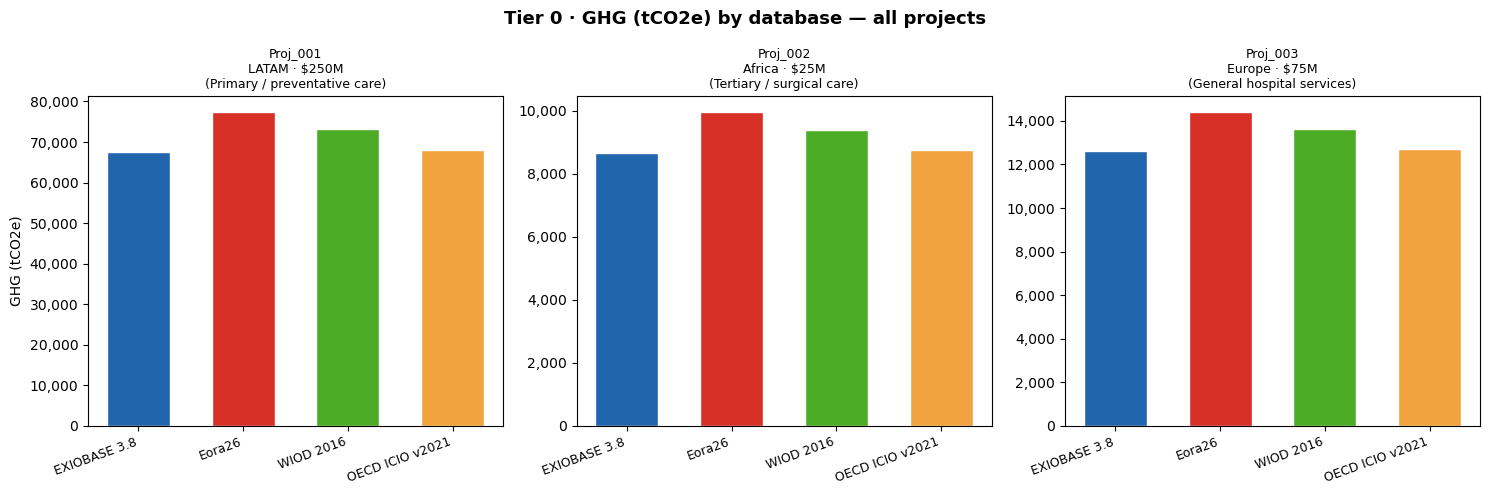

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Tier 0 · GHG (tCO2e) by database — all projects", fontsize=13, fontweight="bold")

for ax, p in zip(axes, PROJECTS):
    sub = t0_df[t0_df["Project"] == p["id"]].reset_index(drop=True)
    ax.bar(range(len(DATABASES)), sub["GHG_tCO2e"],
           color=DB_COLORS, width=0.6, edgecolor="white")
    ax.set_xticks(range(len(DATABASES)))
    ax.set_xticklabels([DB_LABEL[d] for d in DATABASES], rotation=20, ha="right", fontsize=9)
    ax.set_title(f"{p['id']}\n{p['region']} · ${p['invest_usd']/1e6:.0f}M\n({p['care_type']})",
                 fontsize=9)
    if ax is axes[0]:
        ax.set_ylabel("GHG (tCO2e)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

plt.tight_layout()
plt.show()


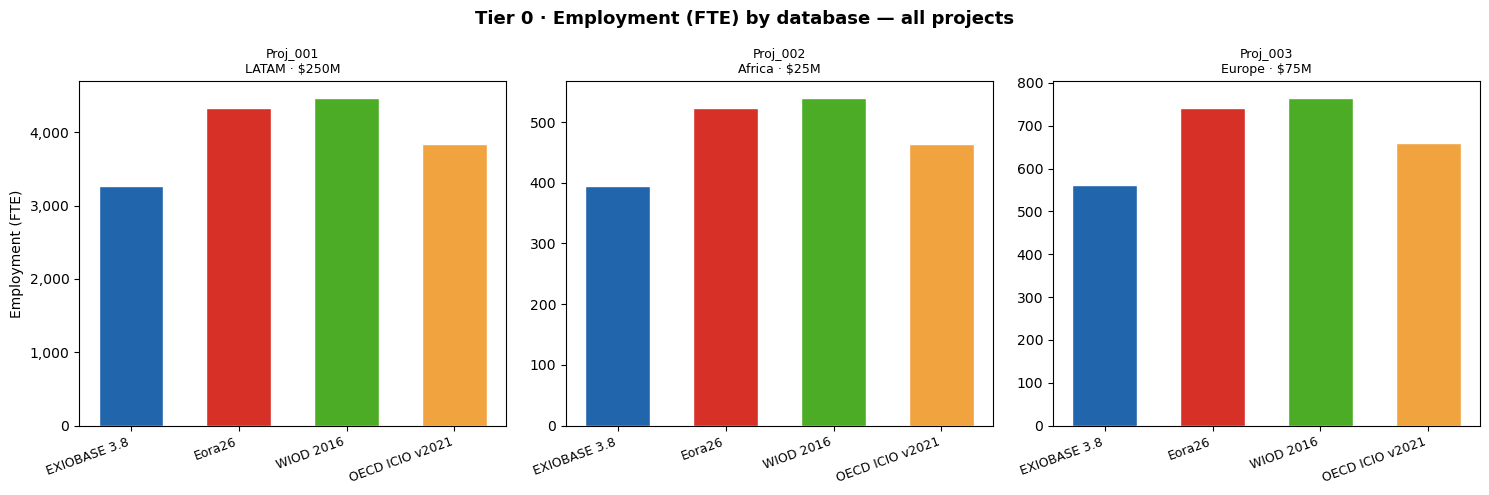

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Tier 0 · Employment (FTE) by database — all projects", fontsize=13, fontweight="bold")

for ax, p in zip(axes, PROJECTS):
    sub = t0_df[t0_df["Project"] == p["id"]].reset_index(drop=True)
    ax.bar(range(len(DATABASES)), sub["Employment_FTE"],
           color=DB_COLORS, width=0.6, edgecolor="white")
    ax.set_xticks(range(len(DATABASES)))
    ax.set_xticklabels([DB_LABEL[d] for d in DATABASES], rotation=20, ha="right", fontsize=9)
    ax.set_title(f"{p['id']}\n{p['region']} · ${p['invest_usd']/1e6:.0f}M", fontsize=9)
    if ax is axes[0]:
        ax.set_ylabel("Employment (FTE)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

plt.tight_layout()
plt.show()


---
## 5 · Tier 1 — First Upstream Round: Tier 0 Spend Aggregated into the Supply Chain

**Formula:** `y₁ = A · y₀`;  for each sector j:
`impact₁[src] = S(src) · (trade_share[src, j] × y₁[j])`

Tier 1 is **not** the direct spend — that is Tier 0.  Tier 1 is what happens
when the Tier 0 payment propagates one round into the upstream economy: the
construction firms and medical equipment manufacturers that received the
Tier 0 payment now buy inputs from their **own** suppliers in different sectors
and different countries.

For health projects this tier is particularly important because:
- **Medical equipment** (Manufacturing sector) has very high import content in
  LATAM and Africa — most diagnostic imaging, surgical robots, and laboratory
  equipment is sourced from Europe, the US, and Japan.  At Tier 1 this import
  leakage becomes visible through the sourcing-country breakdown.
- **Pharmaceuticals and consumables** (partially captured in Agriculture and
  Manufacturing) also flow disproportionately from high-income supplier countries.

**Trade shares (calibrated fallback):**
Derived from the OECD TiVA 2021 database (`IMSH_D` indicator).  For LATAM the
regional import openness is ≈ 22 %; for Africa ≈ 30 %; for Europe ≈ 28 %.
Manufacturing and Mining sectors receive higher foreign shares; Construction and
Water/Waste receive lower foreign shares reflecting local procurement.

When pymrio database files are present under `input_iodb/`, trade shares are
extracted directly from the MRIO Z matrix — no calibrated approximation is used.


In [10]:
t1_rows = []
for p in PROJECTS:
    for db in DATABASES:
        r = tier1_impact(p["invest_usd"], p["sector_code"], p["region"],
                         database=db, iodb_path=IODB)
        t1_rows.append({
            "Project": p["id"], "Region": p["region"], "Stage": p["stage"],
            "Database": DB_LABEL[db],
            "GHG_tCO2e":      r["GHG_tCO2e"],
            "Employment_FTE": r["Employment_FTE"],
            "Water_1000m3":   r["Water_1000m3"],
            "ValueAdded_M$":  r["ValueAdded_M$"],
            "_sourcing":      r["sourcing_summary"],
            "_by_sector":     r["tier1_by_sector"],
        })
t1_df = pd.DataFrame(t1_rows)
print("Tier 1 computed.")


Tier 1 computed.


In [11]:
display(Markdown("### Tier 1 — All projects × all databases"))
cols = ["Project","Region","Database","GHG_tCO2e","Employment_FTE","Water_1000m3","ValueAdded_M$"]
display(t1_df[cols].set_index(["Project","Database"]))


### Tier 1 — All projects × all databases

Region  GHG_tCO2e  Employment_FTE  Water_1000m3  \
Project  Database                                                           
Proj_001 EXIOBASE 3.8      LATAM 33,382.090       1,266.270       265.282   
         Eora26            LATAM 39,014.330       1,733.580       318.667   
         WIOD 2016         LATAM 36,003.390       1,771.750       277.834   
         OECD ICIO v2021   LATAM 33,508.100       1,523.580       284.220   
Proj_002 EXIOBASE 3.8     Africa  3,822.980         149.990        30.056   
         Eora26           Africa  4,463.880         205.500        36.099   
         WIOD 2016        Africa  4,115.850         209.430        31.411   
         OECD ICIO v2021  Africa  3,834.240         180.210        32.150   
Proj_003 EXIOBASE 3.8     Europe  7,480.890         272.460        58.483   
         Eora26           Europe  8,744.940         372.590        69.969   
         WIOD 2016        Europe  8,063.540         380.930        61.222   
         OECD ICIO v2021  Europe  7,506.090         327.900        62.652   

                          ValueAdded_M$  
Project  Database                        
Proj_001 EXIOBASE 3.8            66.976  
         Eora26                  68.359  
         WIOD 2016               67.463  
         OECD ICIO v2021         67.779  
Proj_002 EXIOBASE 3.8             6.889  
         Eora26                   7.030  
         WIOD 2016                6.919  
         OECD ICIO v2021          6.958  
Proj_003 EXIOBASE 3.8            19.981  
         Eora26                  20.384  
         WIOD 2016               20.131  
         OECD ICIO v2021         20.222

In [12]:
display(Markdown("### Tier 1 — Sourcing-country GHG breakdown · all projects (EXIOBASE 3.8)"))
for p in PROJECTS:
    display(Markdown(f"**{p['id']} · {p['region']} · {p['care_type']}**"))
    rec = next(r for r in t1_rows
               if r["Project"] == p["id"] and r["Database"] == "EXIOBASE 3.8")
    src_rows = []
    for region, vals in rec["_sourcing"].items():
        src_rows.append({
            "Sourcing region": region,
            "spend_M$":       vals["spend_M$"],
            "GHG_tCO2e":      vals["GHG_tCO2e"],
            "Employment_FTE": vals["Employment_FTE"],
            "Water_1000m3":   vals["Water_1000m3"],
        })
    display(pd.DataFrame(src_rows).set_index("Sourcing region"))


### Tier 1 — Sourcing-country GHG breakdown · all projects (EXIOBASE 3.8)

**Proj_001 · LATAM · Primary / preventative care**

,spend_M$,GHG_tCO2e,Employment_FTE,Water_1000m3
Sourcing region,,,,
Europe,9.196,"1,732.525",58.215,12.723
LATAM,79.592,"22,637.319",880.988,186.141
Africa,1.672,597.662,22.584,4.438
Asia,16.720,"5,578.548",205.318,42.684
Global,11.286,"2,836.034",99.163,19.297


**Proj_002 · Africa · Tertiary / surgical care**

,spend_M$,GHG_tCO2e,Employment_FTE,Water_1000m3
Sourcing region,,,,
Europe,1.137,215.300,7.168,1.562
LATAM,0.362,109.809,3.855,0.803
Africa,7.251,"2,452.228",101.446,20.076
Asia,2.068,692.978,25.305,5.243
Global,1.396,352.661,12.221,2.371


**Proj_003 · Europe · General hospital services**

,spend_M$,GHG_tCO2e,Employment_FTE,Water_1000m3
Sourcing region,,,,
Europe,25.815,"4,573.121",168.034,37.113
LATAM,0.858,259.293,9.115,1.916
Africa,0.490,175.698,6.581,1.300
Asia,4.904,"1,639.720",59.835,12.502
Global,3.310,833.058,28.899,5.652


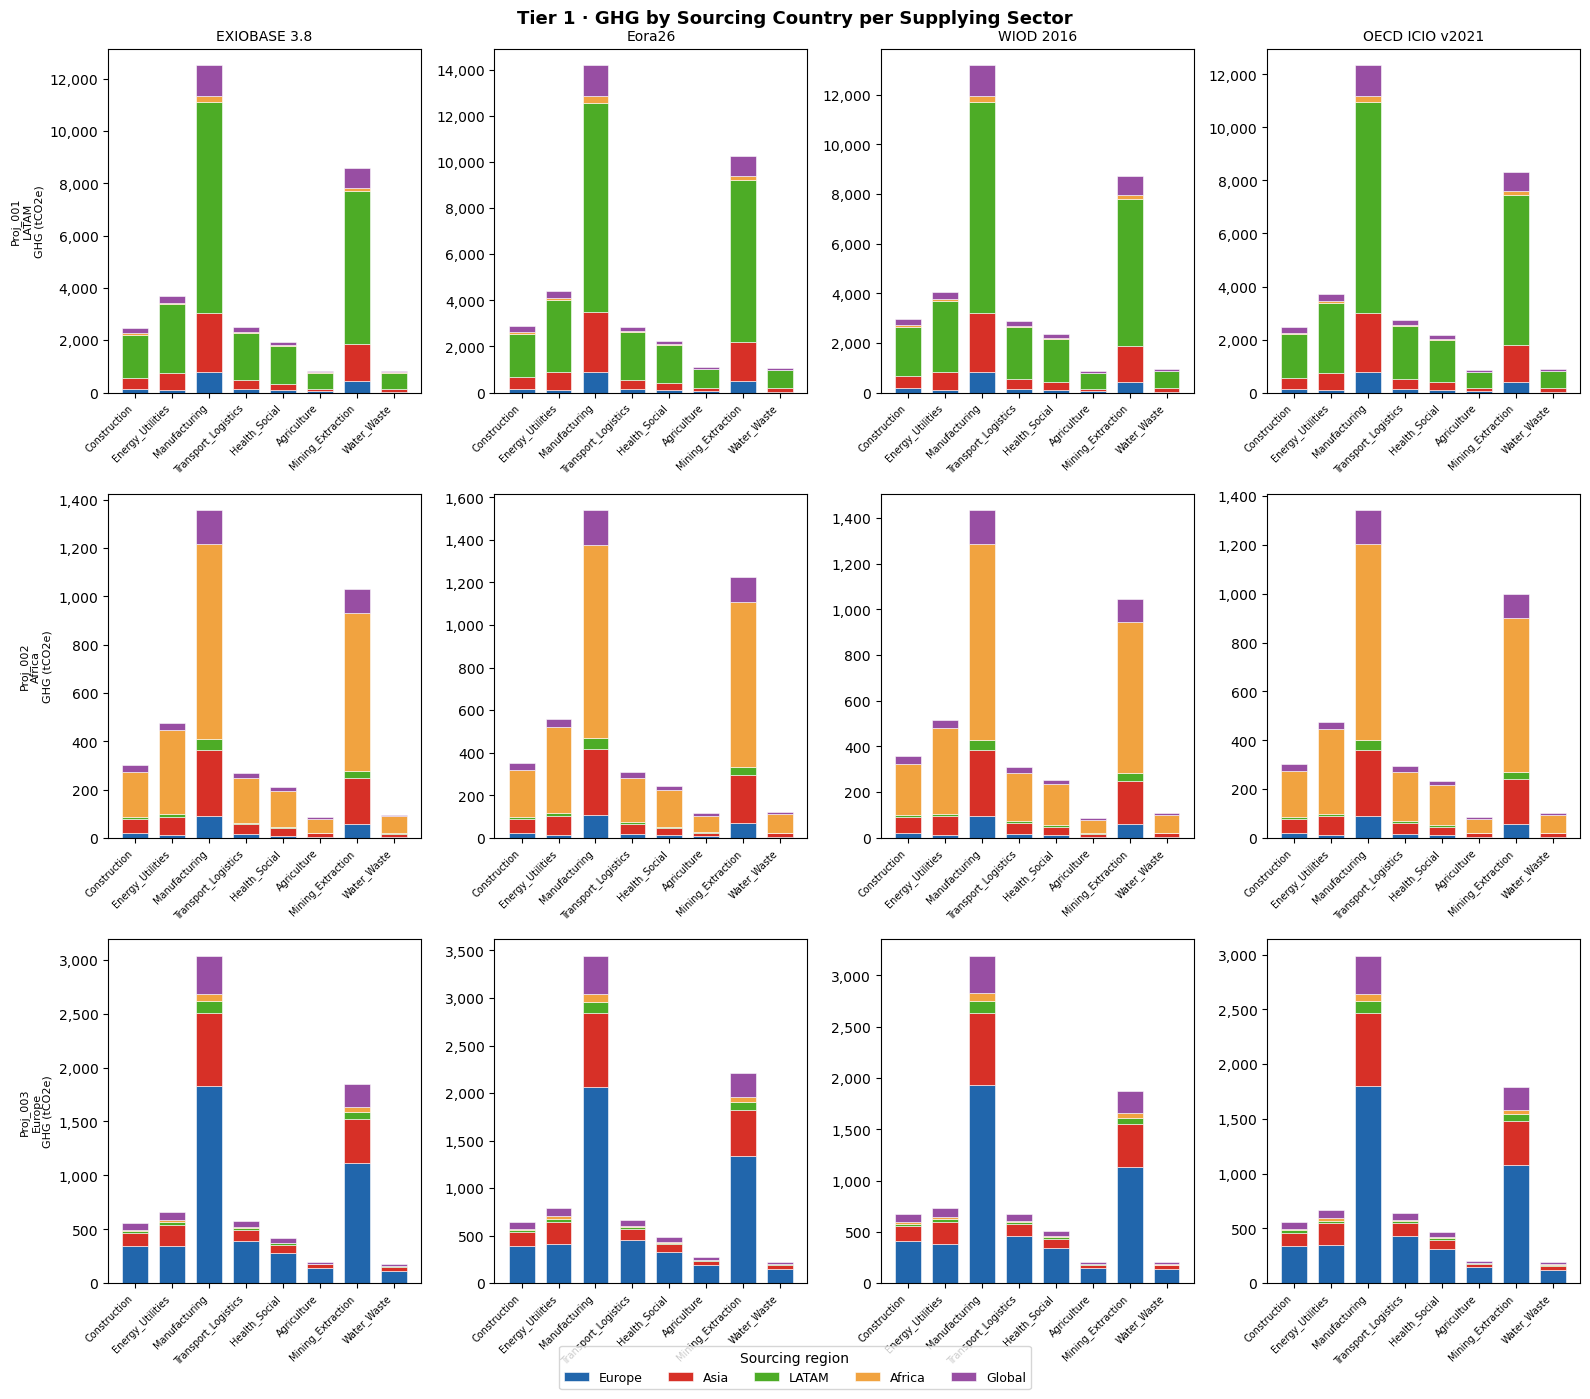

In [13]:
REGION_COLOR = {"Europe":"#2166ac","Asia":"#d73027","LATAM":"#4dac26",
                "Africa":"#f1a340","Global":"#984ea3"}
REGIONS_ORD  = ["Europe","Asia","LATAM","Africa","Global"]

fig, axes = plt.subplots(3, len(DATABASES), figsize=(16, 14), sharey=False)
fig.suptitle("Tier 1 · GHG by Sourcing Country per Supplying Sector",
             fontsize=13, fontweight="bold")

for row_idx, p in enumerate(PROJECTS):
    for col_idx, db in enumerate(DATABASES):
        ax  = axes[row_idx][col_idx]
        rec = next(r for r in t1_rows
                   if r["Project"] == p["id"] and r["Database"] == DB_LABEL[db])
        sectors = list(rec["_by_sector"].keys())
        bottom  = np.zeros(len(sectors))
        for reg in REGIONS_ORD:
            vals = [rec["_by_sector"][s].get(reg, {}).get("GHG_tCO2e", 0) for s in sectors]
            ax.bar(range(len(sectors)), vals, bottom=bottom, label=reg,
                   color=REGION_COLOR.get(reg, "#aaa"), width=0.7,
                   edgecolor="white", lw=0.4)
            bottom += np.array(vals)
        ax.set_xticks(range(len(sectors)))
        ax.set_xticklabels(sectors, rotation=45, ha="right", fontsize=7)
        if col_idx == 0:
            ax.set_ylabel(f"{p['id']}\n{p['region']}\nGHG (tCO2e)", fontsize=8)
        if row_idx == 0:
            ax.set_title(DB_LABEL[db], fontsize=10)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

# Shared legend
handles, labels = axes[0][-1].get_legend_handles_labels()
fig.legend(handles, labels, title="Sourcing region",
           loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.01), fontsize=9)
plt.tight_layout()
plt.show()


---
## 6 · Tier 2 — Second Upstream Round

**Formula:** `y₂ = A² · y₀`

Tier 2 is the supply chain of the Tier 1 suppliers — two rounds back from the
direct investment.  Energy/Utilities and Mining/Extraction gain weight because
virtually every sector requires energy and raw materials as inputs.

For health projects, by Tier 2 the supply chain includes:
- **Ore and raw materials** (Mining_Extraction) feeding the steel and glass used in
  construction and medical devices.
- **Energy generation** inputs for the electricity supply chain.
- **Agricultural inputs** feeding the pharmaceutical supply chain.

**Decay:** Tier 2 totals ≈ 0.52 × Tier 1 totals (spectral radius of A_BASE ≈ 0.52).
Sourcing-country breakdown is not computed at Tier 2 and above; project-region
intensity is applied uniformly.

**WIOD water note:** WIOD 2016 has no dedicated water satellite account.
Water impacts for WIOD use the global `S_BASE` water row — treat as indicative only.


In [14]:
t2_rows = []
for p in PROJECTS:
    for db in DATABASES:
        df2 = tier_impact(p["invest_usd"], p["sector_code"], p["region"],
                          database=db, iodb_path=IODB, tier_from=2, tier_to=2)
        t2_rows.append({
            "Project": p["id"], "Region": p["region"], "Stage": p["stage"],
            "Database": DB_LABEL[db],
            "GHG_tCO2e":      round(df2["GHG_tCO2e"].sum(), 2),
            "Employment_FTE": round(df2["Employment_FTE"].sum(), 2),
            "Water_1000m3":   round(df2["Water_1000m3"].sum(), 4),
            "ValueAdded_M$":  round(df2["ValueAdded_M$"].sum(), 4),
            "_df": df2,
        })
t2_df = pd.DataFrame(t2_rows)

display(Markdown("### Tier 2 — All projects × all databases"))
cols = ["Project","Region","Database","GHG_tCO2e","Employment_FTE","Water_1000m3","ValueAdded_M$"]
display(t2_df[cols].set_index(["Project","Database"]))


### Tier 2 — All projects × all databases

Region  GHG_tCO2e  Employment_FTE  Water_1000m3  \
Project  Database                                                           
Proj_001 EXIOBASE 3.8      LATAM 16,066.390         593.890       129.551   
         Eora26            LATAM 18,983.350         826.680       158.113   
         WIOD 2016         LATAM 17,253.950         831.160       135.663   
         OECD ICIO v2021   LATAM 16,049.990         715.120       138.919   
Proj_002 EXIOBASE 3.8     Africa  1,985.190          77.530        15.848   
         Eora26           Africa  2,346.850         107.980        19.334   
         WIOD 2016        Africa  2,129.640         108.350        16.543   
         OECD ICIO v2021  Africa  1,982.010          93.280        16.955   
Proj_003 EXIOBASE 3.8     Europe  2,974.720         105.350        23.878   
         Eora26           Europe  3,511.830         146.340        28.960   
         WIOD 2016        Europe  3,195.180         147.190        24.990   
         OECD ICIO v2021  Europe  2,971.930         126.880        25.599   

                          ValueAdded_M$  
Project  Database                        
Proj_001 EXIOBASE 3.8            31.139  
         Eora26                  32.199  
         WIOD 2016               31.320  
         OECD ICIO v2021         31.476  
Proj_002 EXIOBASE 3.8             3.221  
         Eora26                   3.332  
         WIOD 2016                3.233  
         OECD ICIO v2021          3.252  
Proj_003 EXIOBASE 3.8             9.303  
         Eora26                   9.614  
         WIOD 2016                9.356  
         OECD ICIO v2021          9.401

In [15]:
display(Markdown("### Tier 2 — Sector detail per project (EXIOBASE 3.8)"))
for p in PROJECTS:
    display(Markdown(f"**{p['id']} · {p['region']} · {p['care_type']}**"))
    df2_proj = next(r["_df"] for r in t2_rows
                    if r["Project"] == p["id"] and r["Database"] == "EXIOBASE 3.8")
    detail_cols = ["supplying_sector","spend_M$","GHG_tCO2e","Employment_FTE",
                   "Water_1000m3","ValueAdded_M$"]
    display(df2_proj[detail_cols].set_index("supplying_sector"))


### Tier 2 — Sector detail per project (EXIOBASE 3.8)

**Proj_001 · LATAM · Primary / preventative care**

,spend_M$,GHG_tCO2e,Employment_FTE,Water_1000m3,ValueAdded_M$
supplying_sector,,,,,
Construction,4.512,"1,155.484",69.362,4.377,2.166
Energy_Utilities,8.303,"1,776.885",42.617,12.778,5.314
Manufacturing,13.656,"5,878.307",117.286,25.695,5.735
Transport_Logistics,6.058,"1,213.475",65.052,4.257,3.635
Health_Social,4.940,793.181,101.305,5.607,3.458
Agriculture,2.620,415.980,68.020,17.156,1.991
Mining_Extraction,11.677,"4,421.857",87.753,25.827,6.539
Water_Waste,3.335,411.221,42.499,33.855,2.301


**Proj_002 · Africa · Tertiary / surgical care**

,spend_M$,GHG_tCO2e,Employment_FTE,Water_1000m3,ValueAdded_M$
supplying_sector,,,,,
Construction,0.464,138.579,9.234,0.558,0.223
Energy_Utilities,0.860,273.342,5.539,1.618,0.551
Manufacturing,1.441,725.627,15.424,3.221,0.605
Transport_Logistics,0.627,140.577,8.450,0.513,0.376
Health_Social,0.507,94.740,13.157,0.686,0.355
Agriculture,0.265,43.711,8.644,2.125,0.202
Mining_Extraction,1.205,516.021,11.280,3.164,0.675
Water_Waste,0.340,52.592,5.803,3.964,0.235


**Proj_003 · Europe · General hospital services**

,spend_M$,GHG_tCO2e,Employment_FTE,Water_1000m3,ValueAdded_M$
supplying_sector,,,,,
Construction,1.354,225.308,11.598,0.788,0.650
Energy_Utilities,2.482,215.776,7.773,2.490,1.588
Manufacturing,4.069,"1,187.567",20.626,4.905,1.709
Transport_Logistics,1.807,245.456,12.830,0.812,1.084
Health_Social,1.472,147.255,16.982,1.028,1.031
Agriculture,0.774,96.747,11.583,2.629,0.588
Mining_Extraction,3.506,783.607,15.551,4.847,1.964
Water_Waste,0.998,73.001,8.407,6.379,0.689


---
## 7 · Tiers 3–10 — Deep Upstream Rounds

**Formula:** `yₙ = Aⁿ · y₀` for n ∈ {3, …, 10}

Each successive tier decays at approximately the spectral radius of the
calibrated A matrix.  For the global EXIOBASE average:

| Tier | Approx. share of Tier 0 signal |
|---|---|
| 3 | ~27 % |
| 4 | ~14 % |
| 5 | ~7 % |
| 6 | ~4 % |
| 7 | ~2 % |
| 8–10 | < 1 % each |

For health projects, Agriculture and Mining/Extraction accumulate at deeper
tiers — pharmaceuticals and medical consumables have long agricultural
raw-material supply chains (plant-derived active ingredients, natural rubber
for gloves, etc.).

The **aggregate** block (sum of Tiers 3–10) is the appropriate figure for
reporting the "deep upstream" supply-chain component.  Beyond Tier 10 the
residual is < 0.5 % for this A matrix.


In [16]:
t310_store = {}   # (project_id, db) → full DataFrame

for p in PROJECTS:
    for db in DATABASES:
        df310 = tier_impact(p["invest_usd"], p["sector_code"], p["region"],
                            database=db, iodb_path=IODB, tier_from=3, tier_to=10)
        t310_store[(p["id"], db)] = df310

print("Tiers 3–10 computed.")


Tiers 3–10 computed.


### Tiers 3–10 · Per-tier GHG decay — all projects (EXIOBASE 3.8)

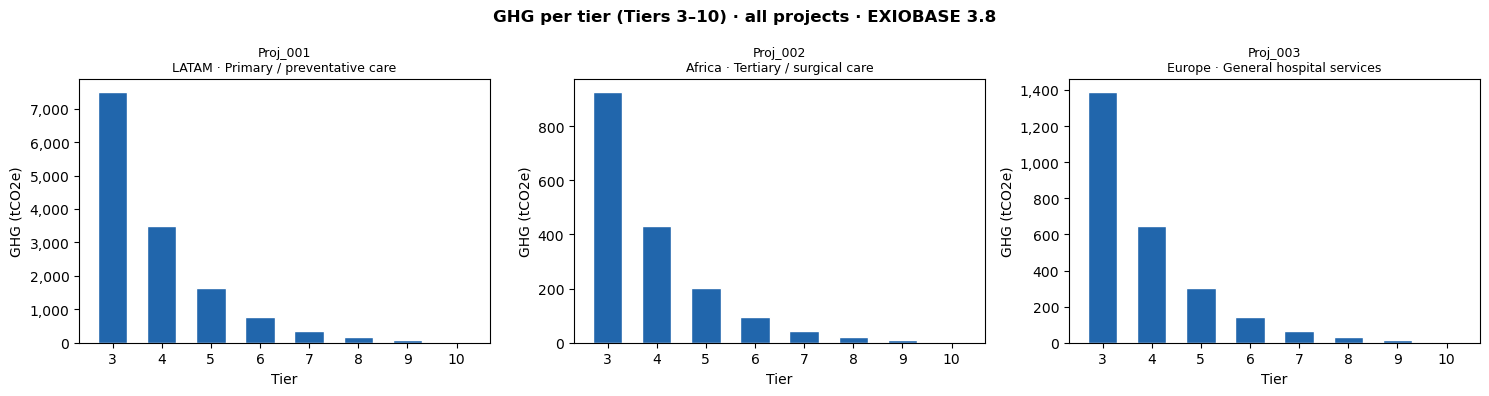

In [17]:
display(Markdown("### Tiers 3–10 · Per-tier GHG decay — all projects (EXIOBASE 3.8)"))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("GHG per tier (Tiers 3–10) · all projects · EXIOBASE 3.8",
             fontsize=12, fontweight="bold")

for ax, p in zip(axes, PROJECTS):
    decay_df = (t310_store[(p["id"], "exiobase")]
                .groupby("tier")[["GHG_tCO2e","Employment_FTE"]]
                .sum().reset_index().set_index("tier"))
    ax.bar(decay_df.index, decay_df["GHG_tCO2e"],
           color="#2166ac", width=0.6, edgecolor="white")
    ax.set_xlabel("Tier")
    ax.set_ylabel("GHG (tCO2e)")
    ax.set_title(f"{p['id']}\n{p['region']} · {p['care_type']}", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

plt.tight_layout()
plt.show()


### Tiers 3–10 · Cross-database GHG decay — Proj_001 (LATAM, Health_Social)

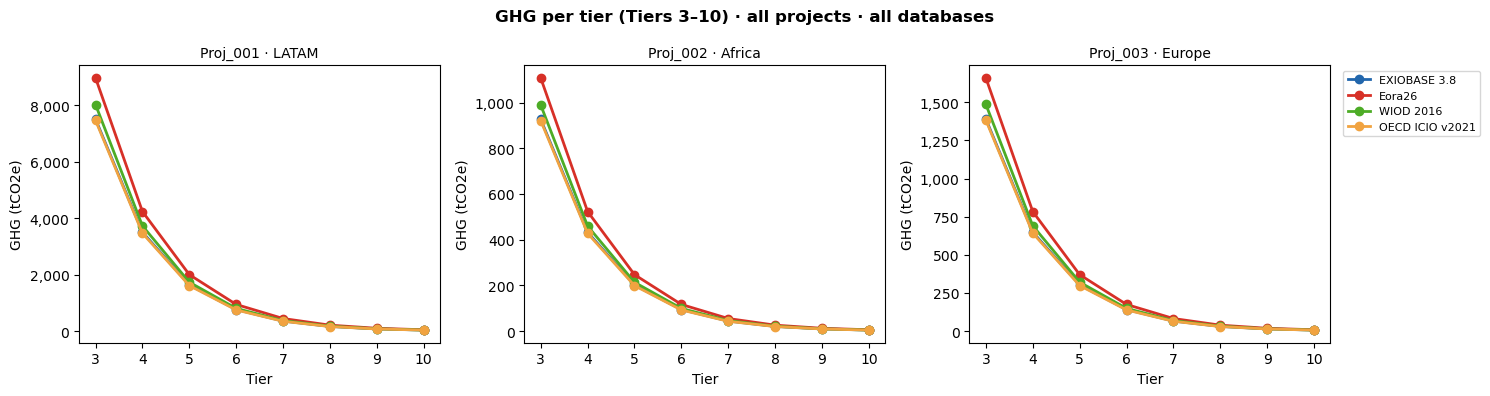

In [18]:
display(Markdown("### Tiers 3–10 · Cross-database GHG decay — Proj_001 (LATAM, Health_Social)"))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("GHG per tier (Tiers 3–10) · all projects · all databases",
             fontsize=12, fontweight="bold")

for ax, p in zip(axes, PROJECTS):
    for db, color in zip(DATABASES, DB_COLORS):
        df310 = t310_store[(p["id"], db)]
        by_tier = df310.groupby("tier")["GHG_tCO2e"].sum().reset_index()
        ax.plot(by_tier["tier"], by_tier["GHG_tCO2e"],
                marker="o", label=DB_LABEL[db], color=color, linewidth=2)
    ax.set_xlabel("Tier")
    ax.set_ylabel("GHG (tCO2e)")
    ax.set_title(f"{p['id']} · {p['region']}", fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

axes[-1].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [19]:
t310_agg_rows = []
for p in PROJECTS:
    for db in DATABASES:
        df310 = t310_store[(p["id"], db)]
        t310_agg_rows.append({
            "Project": p["id"], "Region": p["region"], "Database": DB_LABEL[db],
            "GHG_tCO2e":      round(df310["GHG_tCO2e"].sum(), 2),
            "Employment_FTE": round(df310["Employment_FTE"].sum(), 2),
            "Water_1000m3":   round(df310["Water_1000m3"].sum(), 4),
            "ValueAdded_M$":  round(df310["ValueAdded_M$"].sum(), 4),
        })
t310_agg_df = pd.DataFrame(t310_agg_rows)

display(Markdown("### Tiers 3–10 — Aggregate (sum of Tiers 3 to 10) · all projects × databases"))
display(t310_agg_df.set_index(["Project","Database"]))


### Tiers 3–10 — Aggregate (sum of Tiers 3 to 10) · all projects × databases

Region  GHG_tCO2e  Employment_FTE  Water_1000m3  \
Project  Database                                                           
Proj_001 EXIOBASE 3.8      LATAM 14,037.370         515.780       112.852   
         Eora26            LATAM 16,944.400         734.560       140.896   
         WIOD 2016         LATAM 14,947.900         717.050       117.437   
         OECD ICIO v2021   LATAM 13,908.470         616.970       120.265   
Proj_002 EXIOBASE 3.8     Africa  1,732.950          67.690        13.896   
         Eora26           Africa  2,093.010          96.470        17.354   
         WIOD 2016        Africa  1,843.290          93.970        14.417   
         OECD ICIO v2021  Africa  1,715.990          80.910        14.779   
Proj_003 EXIOBASE 3.8     Europe  2,599.700          91.610        20.814   
         Eora26           Europe  3,135.020         130.210        25.821   
         WIOD 2016        Europe  2,768.570         127.130        21.641   
         OECD ICIO v2021  Europe  2,575.840         109.600        22.170   

                          ValueAdded_M$  
Project  Database                        
Proj_001 EXIOBASE 3.8            27.121  
         Eora26                  28.679  
         WIOD 2016               27.082  
         OECD ICIO v2021         27.222  
Proj_002 EXIOBASE 3.8             2.816  
         Eora26                   2.979  
         WIOD 2016                2.806  
         OECD ICIO v2021          2.824  
Proj_003 EXIOBASE 3.8             8.104  
         Eora26                   8.566  
         WIOD 2016                8.092  
         OECD ICIO v2021          8.132

---
## 8 · Cumulative Analysis — T0 + T1 + T2 + T3–10

Summing across all tier groups gives the full supply-chain footprint,
approximating the complete Scope 3 embodied impact of the health investment.
The residual beyond Tier 10 is < 0.5 % for this A matrix.

The stacked bar chart decomposes total GHG by tier group and database for all
three projects, making cross-database uncertainty immediately visible.

**Cost-per-beneficiary context:**

| Project | Investment | Beneficiaries | Cost/beneficiary | GHG/beneficiary (T0, EXIO) |
|---|---|---|---|---|
| Proj_001 | $250M | 5,000,000 | $50 | shown below |
| Proj_002 | $25M | 3,000 | $8,333 | shown below |
| Proj_003 | $75M | 500,000 | $150 | shown below |

The very different cost-per-beneficiary profiles drive corresponding differences
in absolute GHG — normalising by beneficiary count puts all three projects on a
comparable basis.


In [20]:
cumul_rows = []
for p in PROJECTS:
    for db in DATABASES:
        lbl = DB_LABEL[db]
        g0 = next(r["GHG_tCO2e"]      for r in t0_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        e0 = next(r["Employment_FTE"]  for r in t0_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        w0 = next(r["Water_1000m3"]    for r in t0_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        v0 = next(r["ValueAdded_M$"]   for r in t0_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        g1 = next(r["GHG_tCO2e"]      for r in t1_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        e1 = next(r["Employment_FTE"]  for r in t1_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        w1 = next(r["Water_1000m3"]    for r in t1_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        v1 = next(r["ValueAdded_M$"]   for r in t1_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        g2 = next(r["GHG_tCO2e"]      for r in t2_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        e2 = next(r["Employment_FTE"]  for r in t2_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        w2 = next(r["Water_1000m3"]    for r in t2_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        v2 = next(r["ValueAdded_M$"]   for r in t2_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        r310 = next(r for r in t310_agg_rows if r["Project"]==p["id"] and r["Database"]==lbl)
        cumul_rows.append({
            "Project": p["id"], "Region": p["region"], "Database": lbl,
            "GHG_T0": g0, "GHG_T1": g1, "GHG_T2": g2, "GHG_T3_10": r310["GHG_tCO2e"],
            "GHG_Total": round(g0+g1+g2+r310["GHG_tCO2e"], 2),
            "Emp_T0": e0, "Emp_T1": e1, "Emp_T2": e2, "Emp_T3_10": r310["Employment_FTE"],
            "Emp_Total": round(e0+e1+e2+r310["Employment_FTE"], 2),
            "Wat_Total": round(w0+w1+w2+r310["Water_1000m3"], 4),
            "VA_Total":  round(v0+v1+v2+r310["ValueAdded_M$"], 4),
        })
cumul_df = pd.DataFrame(cumul_rows)

display(Markdown("### Cumulative GHG by tier group (tCO2e)"))
display(cumul_df[["Project","Region","Database",
                  "GHG_T0","GHG_T1","GHG_T2","GHG_T3_10","GHG_Total"]]
        .set_index(["Project","Database"]))

display(Markdown("### Cumulative totals — all four indicators"))
display(cumul_df[["Project","Region","Database","GHG_Total","Emp_Total","Wat_Total","VA_Total"]]
        .set_index(["Project","Database"]))


### Cumulative GHG by tier group (tCO2e)

Region     GHG_T0     GHG_T1     GHG_T2  GHG_T3_10  \
Project  Database                                                              
Proj_001 EXIOBASE 3.8      LATAM 67,525.420 33,382.090 16,066.390 14,037.370   
         Eora26            LATAM 77,402.570 39,014.330 18,983.350 16,944.400   
         WIOD 2016         LATAM 73,156.710 36,003.390 17,253.950 14,947.900   
         OECD ICIO v2021   LATAM 68,107.910 33,508.100 16,049.990 13,908.470   
Proj_002 EXIOBASE 3.8     Africa  8,658.120  3,822.980  1,985.190  1,732.950   
         Eora26           Africa  9,955.620  4,463.880  2,346.850  2,093.010   
         WIOD 2016        Africa  9,380.710  4,115.850  2,129.640  1,843.290   
         OECD ICIO v2021  Africa  8,740.680  3,834.240  1,982.010  1,715.990   
Proj_003 EXIOBASE 3.8     Europe 12,616.990  7,480.890  2,974.720  2,599.700   
         Eora26           Europe 14,411.450  8,744.940  3,511.830  3,135.020   
         WIOD 2016        Europe 13,643.390  8,063.540  3,195.180  2,768.570   
         OECD ICIO v2021  Europe 12,715.300  7,506.090  2,971.930  2,575.840   

                           GHG_Total  
Project  Database                     
Proj_001 EXIOBASE 3.8    131,011.270  
         Eora26          152,344.650  
         WIOD 2016       141,361.950  
         OECD ICIO v2021 131,574.470  
Proj_002 EXIOBASE 3.8     16,199.240  
         Eora26           18,859.360  
         WIOD 2016        17,469.490  
         OECD ICIO v2021  16,272.920  
Proj_003 EXIOBASE 3.8     25,672.300  
         Eora26           29,803.240  
         WIOD 2016        27,670.680  
         OECD ICIO v2021  25,769.160

### Cumulative totals — all four indicators

Region   GHG_Total  Emp_Total  Wat_Total  VA_Total
Project  Database                                                           
Proj_001 EXIOBASE 3.8      LATAM 131,011.270  5,648.870  1,025.379   262.761
         Eora26            LATAM 152,344.650  7,625.270  1,204.880   266.762
         WIOD 2016         LATAM 141,361.950  7,791.240  1,070.343   263.390
         OECD ICIO v2021   LATAM 131,574.470  6,700.840  1,092.810   264.002
Proj_002 EXIOBASE 3.8     Africa  16,199.240    690.110    117.085    26.303
         Eora26           Africa  18,859.360    932.490    137.357    26.718
         WIOD 2016        Africa  17,469.490    951.820    121.828    26.335
         OECD ICIO v2021  Africa  16,272.920    818.590    124.443    26.412
Proj_003 EXIOBASE 3.8     Europe  25,672.300  1,031.290    202.865    78.773
         Eora26           Europe  29,803.240  1,389.790    238.137    79.950
         WIOD 2016        Europe  27,670.680  1,420.560    211.927    78.963
         OECD ICIO v2021  Europe  25,769.160  1,224.140    216.438    79.141

---
## 4b · Optional Indicators (database-specific satellite accounts)

Additional indicators are served when the selected database provides the relevant
satellite extension beyond the core four (GHG / Employment / Water / Value Added).

| Database | Additional indicators | Unit |
|---|---|---|
| EXIOBASE / iopy ExioBase | `Energy_TJ` — energy input; `NOx_t` — nitrogen-oxide air emissions | TJ / t per M$ |
| WIOD | `Emp_HighSkill_FTE`, `Emp_MedSkill_FTE`, `Emp_LowSkill_FTE` — skill-level employment | FTE per M$ |
| Eora26 / OECD | `LaborIncome_M$` — labour compensation (wages + salaries) | M$ per M$ |

In [21]:
# ── Optional extended indicators from database-specific satellite accounts ──
unit_map = {"Energy_TJ":"TJ","NOx_t":"t","Emp_HighSkill_FTE":"FTE",
            "Emp_MedSkill_FTE":"FTE","Emp_LowSkill_FTE":"FTE","LaborIncome_M$":"M$"}

opt_rows = []
for row in t0_rows:
    opt = row["_r"].get("optional_indicators", {})
    if not opt:
        continue
    opt_rows.append({"Project": row["Project"], "Database": row["Database"], **opt})

if opt_rows:
    opt_df = pd.DataFrame(opt_rows)
    ind_cols = [c for c in opt_df.columns if c not in ("Project","Database")]
    opt_df[ind_cols] = opt_df[ind_cols].round(1)
    units_row = {c: f"[{unit_map.get(c,'?')}]" for c in ind_cols}
    units_row.update({"Project":"", "Database":"unit"})
    display(Markdown("### Tier 0 — Optional indicators by project and database"))
    display(pd.concat([pd.DataFrame([units_row]), opt_df],
                       ignore_index=True).set_index(["Project","Database"]))
else:
    avail_dbs = list({r["Database"] for r in t0_rows})
    display(Markdown(f"*No optional indicators available for the selected database(s): {avail_dbs}*"))

### Tier 0 — Optional indicators by project and database

Energy_TJ   NOx_t LaborIncome_M$ Emp_HighSkill_FTE  \
Project  Database                                                             
         unit                 [TJ]     [t]           [M$]             [FTE]   
Proj_001 EXIOBASE 3.8      764.200 336.400            NaN               NaN   
         Eora26                NaN     NaN         57.600               NaN   
         WIOD 2016             NaN     NaN            NaN           856.100   
         OECD ICIO v2021       NaN     NaN         61.800               NaN   
Proj_002 EXIOBASE 3.8       93.000  38.400            NaN               NaN   
         Eora26                NaN     NaN          4.200               NaN   
         WIOD 2016             NaN     NaN            NaN            83.900   
         OECD ICIO v2021       NaN     NaN          4.600               NaN   
Proj_003 EXIOBASE 3.8      149.800  54.400            NaN               NaN   
         Eora26                NaN     NaN         24.200               NaN   
         WIOD 2016             NaN     NaN            NaN           245.100   
         OECD ICIO v2021       NaN     NaN         26.000               NaN   

                         Emp_MedSkill_FTE Emp_LowSkill_FTE  
Project  Database                                           
         unit                       [FTE]            [FTE]  
Proj_001 EXIOBASE 3.8                 NaN              NaN  
         Eora26                       NaN              NaN  
         WIOD 2016              1,228.000          903.400  
         OECD ICIO v2021              NaN              NaN  
Proj_002 EXIOBASE 3.8                 NaN              NaN  
         Eora26                       NaN              NaN  
         WIOD 2016                118.300           81.300  
         OECD ICIO v2021              NaN              NaN  
Proj_003 EXIOBASE 3.8                 NaN              NaN  
         Eora26                       NaN              NaN  
         WIOD 2016                363.700          274.000  
         OECD ICIO v2021              NaN              NaN

In [22]:
display(Markdown("### GHG per beneficiary (tCO2e / person) — EXIOBASE 3.8, cumulative Tiers 0–10"))
ben_rows = []
for p in PROJECTS:
    row = next(r for r in cumul_rows if r["Project"]==p["id"] and r["Database"]=="EXIOBASE 3.8")
    ben_rows.append({
        "Project":           p["id"],
        "Region":            p["region"],
        "Care type":         p["care_type"],
        "Beneficiaries":     p["beneficiaries"],
        "GHG_Total_tCO2e":   row["GHG_Total"],
        "GHG_per_ben_kgCO2e": round(row["GHG_Total"] / p["beneficiaries"] * 1000, 2),
        "Emp_Total_FTE":     row["Emp_Total"],
        "Emp_per_MUSD":      round(row["Emp_Total"] / (p["invest_usd"] / 1e6), 1),
    })
display(pd.DataFrame(ben_rows).set_index("Project"))


### GHG per beneficiary (tCO2e / person) — EXIOBASE 3.8, cumulative Tiers 0–10

,Region,Care type,Beneficiaries,GHG_Total_tCO2e,GHG_per_ben_kgCO2e,Emp_Total_FTE,Emp_per_MUSD
Project,,,,,,,
Proj_001,LATAM,Primary / preventative care,5000000,"131,011.270",26.200,"5,648.870",22.600
Proj_002,Africa,Tertiary / surgical care,3000,"16,199.240","5,399.750",690.110,27.600
Proj_003,Europe,General hospital services,500000,"25,672.300",51.340,"1,031.290",13.800


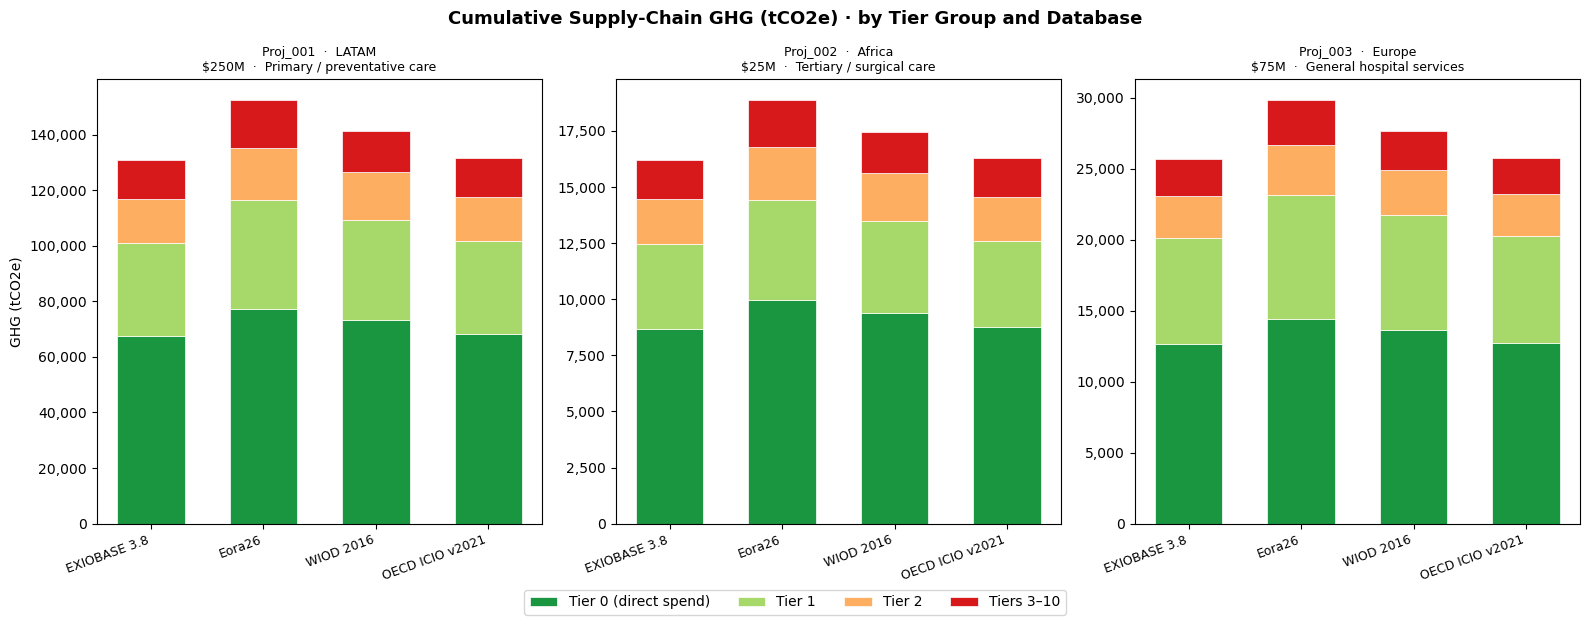

In [23]:
TIER_COLOR = {"T0": "#1a9641", "T1": "#a6d96a", "T2": "#fdae61", "T3_10": "#d7191c"}
TIER_LABEL = {"T0": "Tier 0 (direct spend)", "T1": "Tier 1",
              "T2": "Tier 2", "T3_10": "Tiers 3–10"}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Cumulative Supply-Chain GHG (tCO2e) · by Tier Group and Database",
             fontsize=13, fontweight="bold")

for ax, p in zip(axes, PROJECTS):
    sub    = cumul_df[cumul_df["Project"] == p["id"]].reset_index(drop=True)
    x      = range(len(DATABASES))
    bottom = np.zeros(len(DATABASES))
    for tier_key in ["T0","T1","T2","T3_10"]:
        col  = f"GHG_{tier_key}"
        vals = sub[col].values
        ax.bar(x, vals, bottom=bottom, label=TIER_LABEL[tier_key],
               color=TIER_COLOR[tier_key], width=0.6, edgecolor="white", linewidth=0.5)
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels([DB_LABEL[d] for d in DATABASES], rotation=20, ha="right", fontsize=9)
    ax.set_title(f"{p['id']}  ·  {p['region']}\n${p['invest_usd']/1e6:.0f}M  ·  {p['care_type']}",
                 fontsize=9)
    if ax is axes[0]:
        ax.set_ylabel("GHG (tCO2e)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.04), fontsize=10, frameon=True)
plt.tight_layout()
plt.show()
